# Read in data set 

In [1]:
%%capture
import json
import numpy as np
import nd_python_avon as nd
import matplotlib.pyplot as plt

In [2]:
datas = ['comix3', 'comixa', 'comixb', 'poly'] #Reopen, lockdown 2020, lockdown 2021, polymod
## choose a data set to analyse
data = datas[0]
buckets = np.array([5,12,18,30,40,50,60,70]) # age brackets for analysis

## read in optimal number of components for each age group (pre fitted using BIC)
with open(f'input_data/gmm/optimal_components_{data}_log_smalldur.json', 'r') as f:
    tmp = json.load(f)
optimal_num_components = tmp[data]

## read in data set of ego networks and set of duration properties for <1 hour contacts
with open(f'input_data/egos/{data}_dur_small.json', 'r') as f:
    egos = json.load(f)
props = np.genfromtxt(f'input_data/durations/{data}.csv', delimiter=',')

## can read in your own data set and create ego networks using the function below, but for now we will use the preprocessed data sets
# import pandas as pd
# egos, contact_matrix = nd.fit_to_data(input_file_path=f'input_data/{data}.csv', buckets = np.array([5,12,18,30,40,50,60,70]), duration=True)

print('Random individual')
i = np.random.randint(0, len(egos))
# age group, number of contacts with each age duration pair, and total degree
print(egos[i])

Random individual
{'age': 7, 'contacts': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 2.0, 0.0, 0.0, 4.0, 0.0, 1.0], 'degree': 12.0}


# Build Network of stubs with Gaussian Mixture Model

In [3]:
## define network size and partitions of populations age groups
n = 1000
partitions = [0.058*n, 0.145*n, 0.212*n, 0.364*n, 0.497*n, 0.623*n, 0.759*n, 0.866*n, n] # taken from UK census data

## sample desired ego networks for population
samples = nd.sample_egos_gmm(egos=egos, partitions=partitions, optimal_num_components=optimal_num_components)

# Connect network and run outbreak

In [5]:
## choose outbreak parameters
tau, gamma, sigma, num_infected = 1, 1/4, 1, 1

output = nd.small_dur_gillesp(samples, partitions=partitions, num_dur=3, tau=tau, gamma=gamma, sigma=sigma, num_infec=num_infected, props=props.tolist())

In [7]:
print(output.keys())

dict_keys(['adjacency_matrix', 'degrees', 'frequency_distribution', 'partitions', 'ages', 'disease_from', 'generation', 'parameters', 'secondary_cases', 'sir', 'i_events', 'r_events', 'e_events', 'ts'])


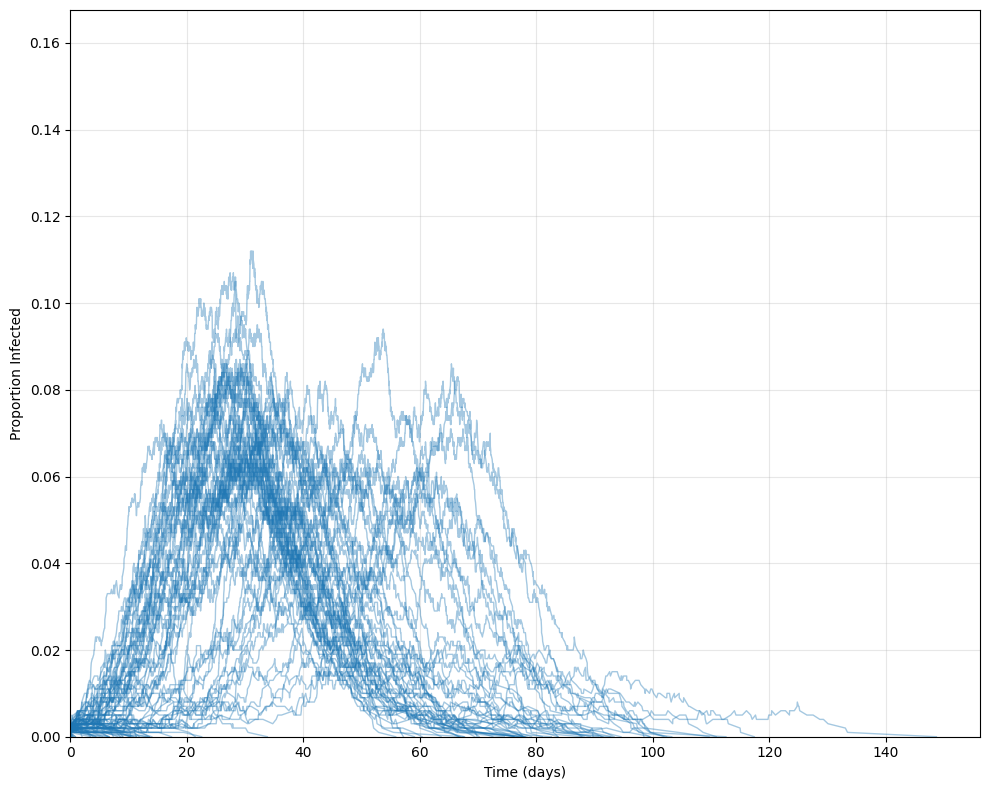

In [ ]:
from collections import defaultdict

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for i in range(100):
    res = nd.small_dur_gillesp(samples, partitions=partitions, num_dur=3, tau=tau, gamma=gamma, sigma=sigma, num_infec=num_infected, props=props.tolist())

    ax.plot(res["ts"], [a[2]/n for a in res['sir']], color='tab:blue', alpha=0.4, linewidth=1)

ax.plot([-1], [-1], label='GMM Duration', color='tab:orange', linewidth=4)
ax.plot([-1], [-1], label='SBM Duration', color='tab:blue', linewidth=4)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Proportion Infected")
ax.set_ylim(0, ax.get_ylim()[1])
ax.set_xlim(0, ax.get_xlim()[1])
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
plt.show()